In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
FIGURE_DIR = PROJECT_ROOT / 'figures'
FIGURE_DIR.mkdir(exist_ok=True)

np.random.seed(0)

In [4]:
N = 50

true_w = 2.0
true_b = 1.0

noise_std = 0.8

x = np.linspace(-3,3,N)

epsilon = noise_std * np.random.randn(N)

y = true_w * x + true_b + epsilon

x.shape,epsilon.shape,y.shape,x[:5],y[:5]

((50,),
 (50,),
 (50,),
 array([-3.        , -2.87755102, -2.75510204, -2.63265306, -2.51020408]),
 array([-3.58875812, -4.43497627, -3.72721369, -2.47259156, -2.52636177]))

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp1_step1_raw_data.png


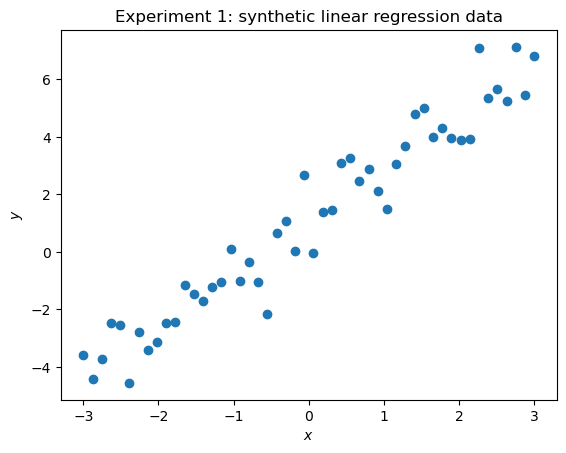

In [8]:
fig, ax = plt.subplots()

ax.scatter(x,y)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Experiment 1: synthetic linear regression data')

fig_path = FIGURE_DIR / 'exp1_step1_raw_data.png'
fig.savefig(fig_path,dpi=200,bbox_inches='tight')

print("Saved figure to:", fig_path)
plt.show()

In [16]:
ones = np.ones(N)

X = np.column_stack([x,ones])

theta_true = np.array([true_w,true_b])

y_noiseless = X @ theta_true


print("x shape:", x.shape)
print("y shape:", y.shape)
print("ones shape:", ones.shape)
print("X shape:", X.shape)
print("theta_true shape:", theta_true.shape)
print("y_noiseless shape:", y_noiseless.shape)

print("\nFirst 5 rows of X:")
print(X[:5])

print("\nFirst 5 noiseless y values:")
print(y_noiseless[:5])

y_noiseless

x shape: (50,)
y shape: (50,)
ones shape: (50,)
X shape: (50, 2)
theta_true shape: (2,)
y_noiseless shape: (50,)

First 5 rows of X:
[[-3.          1.        ]
 [-2.87755102  1.        ]
 [-2.75510204  1.        ]
 [-2.63265306  1.        ]
 [-2.51020408  1.        ]]

First 5 noiseless y values:
[-5.         -4.75510204 -4.51020408 -4.26530612 -4.02040816]


array([-5.        , -4.75510204, -4.51020408, -4.26530612, -4.02040816,
       -3.7755102 , -3.53061224, -3.28571429, -3.04081633, -2.79591837,
       -2.55102041, -2.30612245, -2.06122449, -1.81632653, -1.57142857,
       -1.32653061, -1.08163265, -0.83673469, -0.59183673, -0.34693878,
       -0.10204082,  0.14285714,  0.3877551 ,  0.63265306,  0.87755102,
        1.12244898,  1.36734694,  1.6122449 ,  1.85714286,  2.10204082,
        2.34693878,  2.59183673,  2.83673469,  3.08163265,  3.32653061,
        3.57142857,  3.81632653,  4.06122449,  4.30612245,  4.55102041,
        4.79591837,  5.04081633,  5.28571429,  5.53061224,  5.7755102 ,
        6.02040816,  6.26530612,  6.51020408,  6.75510204,  7.        ])

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp1_step1_noiseless_data.png


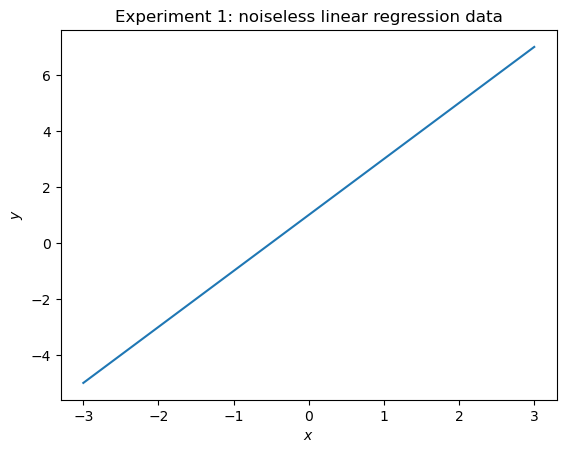

In [24]:
fig, ax = plt.subplots()

ax.plot(x,y_noiseless)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Experiment 1: noiseless linear regression data')

fig_path = FIGURE_DIR / 'exp1_step1_noiseless_data.png'
fig.savefig(fig_path,dpi=200,bbox_inches='tight')

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp1_step1_raw_and_noiseless_data.png


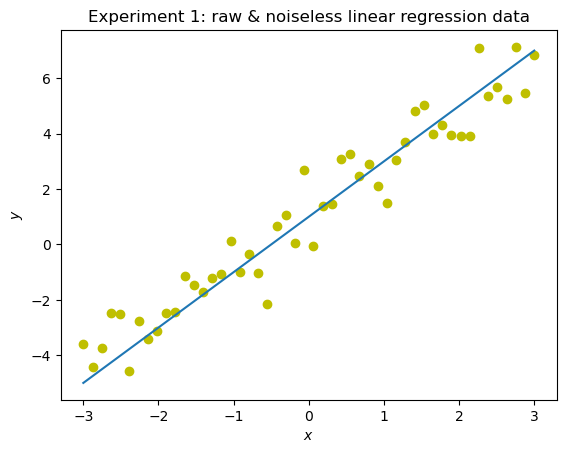

In [26]:
fig, ax = plt.subplots()

ax.plot(x,y_noiseless)
ax.scatter(x,y,color='y')

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Experiment 1: raw & noiseless linear regression data')

fig_path = FIGURE_DIR / 'exp1_step1_raw_and_noiseless_data.png'
fig.savefig(fig_path,dpi=200,bbox_inches='tight')

print("Saved figure to:", fig_path)
plt.show()

In [30]:
theta_hat, residuals, rank, singular_values = np.linalg.lstsq(X,y,rcond=None)

w_hat,b_hat = theta_hat

y_pred = X @ theta_hat

train_mse = np.mean((y-y_pred)**2)

print("theta_hat:", theta_hat)
print("w_hat:", w_hat)
print("b_hat:", b_hat)
print("true_w:", true_w)
print("true_b:", true_b)

print("\nShapes:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("theta_hat shape:", theta_hat.shape)
print("y_pred shape:", y_pred.shape)

print("\nLeast squares diagnostics:")
print("residuals:", residuals)
print("rank:", rank)
print("singular values:", singular_values)

print("\nTraining MSE:", train_mse)

theta_hat: [1.81178367 1.11244742]
w_hat: 1.8117836676013082
b_hat: 1.1124474178504775
true_w: 2.0
true_b: 1.0

Shapes:
X shape: (50, 2)
y shape: (50,)
theta_hat shape: (2,)
y_pred shape: (50,)

Least squares diagnostics:
residuals: [35.00696073]
rank: 2
singular values: [12.49489692  7.07106781]

Training MSE: 0.7001392146740105


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp1_step3_fitted_line.png


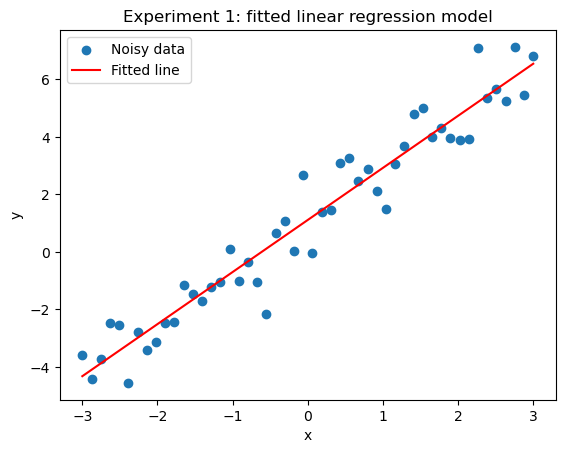

In [34]:
fig, ax = plt.subplots()

ax.scatter(x, y, label="Noisy data")
ax.plot(x, y_pred, label="Fitted line",color = 'red')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Experiment 1: fitted linear regression model")
ax.legend()

fig_path = FIGURE_DIR / "exp1_step3_fitted_line.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [38]:
residuals_vector = y - y_pred

train_mse_check = np.mean(residuals_vector**2)
train_rmse = np.sqrt(train_mse_check)

print("y shape:", y.shape)
print("y_pred shape:", y_pred.shape)
print("residuals_vector shape:", residuals_vector.shape)

print("Training MSE:", train_mse_check)
print("Training RMSE:", train_rmse)

print("\nFirst 5 true y values:")
print(y[:5])

print("\nFirst 5 predicted y values:")
print(y_pred[:5])

print("\nFirst 5 residuals:")
print(residuals_vector[:5])

y shape: (50,)
y_pred shape: (50,)
residuals_vector shape: (50,)
Training MSE: 0.7001392146740105
Training RMSE: 0.8367432190785955

First 5 true y values:
[-3.58875812 -4.43497627 -3.72721369 -2.47259156 -2.52636177]

First 5 predicted y values:
[-4.32290358 -4.10105252 -3.87920146 -3.6573504  -3.43549934]

First 5 residuals:
[ 0.73414546 -0.33392375  0.15198777  1.18475884  0.90913757]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp1_step4_prediction_vs_truth.png


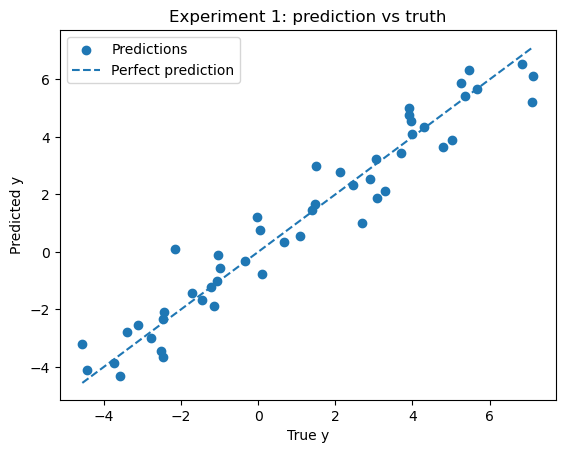

In [40]:
fig, ax = plt.subplots()

ax.scatter(y, y_pred, label="Predictions")

# Perfect prediction line
min_value = min(y.min(), y_pred.min())
max_value = max(y.max(), y_pred.max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

ax.set_xlabel("True y")
ax.set_ylabel("Predicted y")
ax.set_title("Experiment 1: prediction vs truth")
ax.legend()

fig_path = FIGURE_DIR / "exp1_step4_prediction_vs_truth.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [46]:
def mse(y_true,y_pred):
    errors = y_true-y_pred
    return np.mean(errors**2)

y_pred_fitted = X @ theta_hat
y_pred_true_params = X @ theta_true

theta_bad = np.array([0.0,0.0])
y_pred_bad = X @ theta_bad

mse_fitted = mse(y, y_pred_fitted)
mse_true_params = mse(y, y_pred_true_params)
mse_bad = mse(y, y_pred_bad)

print("theta_true:", theta_true)
print("theta_hat:", theta_hat)
print("theta_bad:", theta_bad)

print("\nShapes:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("theta_true shape:", theta_true.shape)
print("theta_hat shape:", theta_hat.shape)
print("theta_bad shape:", theta_bad.shape)
print("y_pred_fitted shape:", y_pred_fitted.shape)
print("y_pred_true_params shape:", y_pred_true_params.shape)
print("y_pred_bad shape:", y_pred_bad.shape)

print("\nMSE comparison:")
print("MSE using fitted parameters:", mse_fitted)
print("MSE using true parameters:", mse_true_params)
print("MSE using bad parameters:", mse_bad)

theta_true: [2. 1.]
theta_hat: [1.81178367 1.11244742]
theta_bad: [0. 0.]

Shapes:
X shape: (50, 2)
y shape: (50,)
theta_true shape: (2,)
theta_hat shape: (2,)
theta_bad shape: (2,)
y_pred_fitted shape: (50,)
y_pred_true_params shape: (50,)
y_pred_bad shape: (50,)

MSE comparison:
MSE using fitted parameters: 0.7001392146740105
MSE using true parameters: 0.8233976023855988
MSE using bad parameters: 12.18730477629065


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp1_step5_parameter_comparison.png


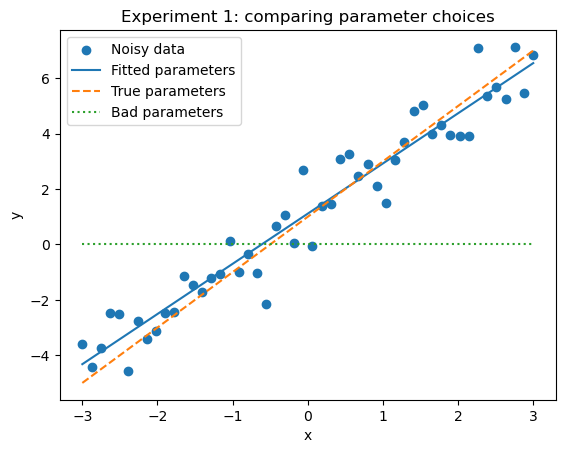

In [50]:
fig, ax = plt.subplots()

ax.scatter(x, y, label="Noisy data")
ax.plot(x, y_pred_fitted, label="Fitted parameters")
ax.plot(x, y_pred_true_params, linestyle="--", label="True parameters")
ax.plot(x, y_pred_bad, linestyle=":", label="Bad parameters")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Experiment 1: comparing parameter choices")
ax.legend()

fig_path = FIGURE_DIR / "exp1_step5_parameter_comparison.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()